# BAW Notebook 00a: Multi-Structure SASA Analysis

**Purpose:** Build a consensus solvent accessibility profile for a target protein
by aligning multiple PDB structures to the canonical UniProt sequence and
averaging SASA values across all structures.

**Why this matters:** A single crystal structure gives a SASA snapshot of one
conformation. Residues that appear buried in one structure (e.g. Tyr119 and
Trp312 in 1S0I which are occluded by the substrate) may be genuinely accessible
in other conformations. Multi-structure averaging gives a reliable picture of
which residues are accessible across the conformational ensemble.

**Input:**
- UniProt accession number (fetched automatically from UniProt REST API)
- Two or more PDB files of the same protein (different conformations, mutants,
  ligand states)

**Output:**
- `{target_label}_consensus_sasa.json` — per-residue consensus SASA profile
  in canonical UniProt numbering, ready for Notebook 01

**Notebook 01 integration:** Notebook 01 automatically loads this file if it
exists in the data directory and uses the consensus SASA instead of
single-structure SASA for candidate pool selection.


In [13]:
# Cell 1: Imports

import os
import sys
import json
import subprocess
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from collections import defaultdict

from Bio.PDB import PDBParser, PPBuilder
from Bio.PDB.SASA import ShrakeRupley
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')

# ── PowerShell popup helpers ────────────────────────────────────────────────
def ps_browse_files_multi(title="Select PDB files"):
    """Open a Windows multi-select file dialog via PowerShell."""
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.OpenFileDialog
$d.Title = "{title}"
$d.Filter = "PDB files|*.pdb|All files|*.*"
$d.Multiselect = $true
$d.ShowDialog() | Out-Null
$d.FileNames -join "|"
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    raw = r.stdout.strip()
    if not raw:
        return []
    paths = []
    for p in raw.split("|"):
        p = p.strip()
        if not p:
            continue
        w = subprocess.run(["wslpath", p], capture_output=True, text=True)
        wsl = w.stdout.strip()
        if wsl:
            paths.append(wsl)
    return paths

def ps_browse_folder(title="Select output folder"):
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.FolderBrowserDialog
$d.Description = "{title}"
$d.ShowNewFolderButton = $true
$d.ShowDialog() | Out-Null
Write-Output $d.SelectedPath
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    p = r.stdout.strip()
    if not p:
        return None
    w = subprocess.run(["wslpath", p], capture_output=True, text=True)
    return w.stdout.strip() or None

print("Imports loaded.")


Imports loaded.


In [14]:
# Cell 2: Configuration

W = dict(style={'description_width': '160px'})

target_name_w = widgets.Text(
    value='', description='Target name:',
    placeholder='e.g. Trans-sialidase',
    layout=widgets.Layout(width='400px'), **W)

target_label_w = widgets.Text(
    value='', description='File label:',
    placeholder='e.g. ts',
    layout=widgets.Layout(width='300px'), **W)

uniprot_w = widgets.Text(
    value='', description='UniProt accession:',
    placeholder='e.g. Q26966',
    layout=widgets.Layout(width='320px'), **W)

sasa_threshold_w = widgets.FloatSlider(
    value=0.15, min=0.05, max=0.50, step=0.01,
    description='SASA threshold:',
    readout_format='.2f',
    layout=widgets.Layout(width='420px'), **W)

confirm_btn = widgets.Button(
    description='Confirm', button_style='success',
    layout=widgets.Layout(width='160px', height='34px'))
conf_out = widgets.Output()

def on_confirm(_):
    global TARGET_NAME, TARGET_LABEL, UNIPROT_ACCESSION, SASA_THRESHOLD
    TARGET_NAME        = target_name_w.value.strip()
    TARGET_LABEL       = target_label_w.value.strip()
    UNIPROT_ACCESSION  = uniprot_w.value.strip()
    SASA_THRESHOLD     = sasa_threshold_w.value
    with conf_out:
        clear_output()
        print(f'Configuration confirmed.')
        print(f'  Target     : {TARGET_NAME}  (label: {TARGET_LABEL})')
        print(f'  UniProt    : {UNIPROT_ACCESSION}')
        print(f'  SASA threshold: {SASA_THRESHOLD}')

confirm_btn.on_click(on_confirm)

# Initialise with defaults
TARGET_NAME       = target_name_w.value
TARGET_LABEL      = target_label_w.value
UNIPROT_ACCESSION = uniprot_w.value
SASA_THRESHOLD    = sasa_threshold_w.value

display(widgets.VBox([
    widgets.HTML('<h3>Notebook 00a — Configuration</h3>'),
    target_name_w, target_label_w, uniprot_w, sasa_threshold_w,
    widgets.HTML('<hr>'),
    widgets.HTML(
        '<i>Seed residues and sphere radius are defined in Cell 5b '
        'after structures are loaded.</i>'),
    confirm_btn, conf_out
]))


In [15]:
# Cell 3: Select output directory and PDB files

out = widgets.Output()
display(out)

# Output directory
with out:
    print('Select output directory...')
output_dir_str = ps_browse_folder('Select output directory for Notebook 00a results')
with out:
    if output_dir_str:
        output_dir = Path(output_dir_str)
    else:
        output_dir = Path.home() / 'BasementAntibodyWorks' / 'data' / TARGET_LABEL
        print(f'Using default: {output_dir}')
output_dir.mkdir(parents=True, exist_ok=True)
with out:
    print(f'Output dir: {output_dir}')

# PDB files — multi-select
with out:
    print()
    print('Select PDB files (hold Ctrl to select multiple)...')
pdb_paths = ps_browse_files_multi(
    title=f'Select PDB structures for {TARGET_NAME} (Ctrl = multi-select)')
with out:
    if not pdb_paths:
        raise FileNotFoundError('No PDB files selected. Re-run this cell.')
    print(f'Selected {len(pdb_paths)} structure(s):')
    for p in pdb_paths:
        print(f'  {Path(p).name}')


Output()

In [17]:
# Cell 4: Fetch canonical sequence from UniProt

print(f'Fetching canonical sequence for {UNIPROT_ACCESSION} from UniProt...')

url = f'https://rest.uniprot.org/uniprotkb/{UNIPROT_ACCESSION}.fasta'
response = requests.get(url, timeout=30)

if response.status_code != 200:
    raise ValueError(
        f'UniProt fetch failed (status {response.status_code}).\n'
        f'Check accession {UNIPROT_ACCESSION} at https://www.uniprot.org'
    )

fasta_lines = response.text.strip().split('\n')
uniprot_header = fasta_lines[0]
uniprot_seq = ''.join(fasta_lines[1:])

print(f'Header  : {uniprot_header[:80]}')
print(f'Length  : {len(uniprot_seq)} amino acids')
print(f'Sequence: {uniprot_seq[:60]}...')


Fetching canonical sequence for Q26966 from UniProt...
Header  : >tr|Q26966|Q26966_TRYCR Trans-sialidase OS=Trypanosoma cruzi OX=5693 PE=1 SV=1
Length  : 642 amino acids
Sequence: MLAPGSSRVELFKRQSSKVPFEKDGKVTERVVHSFRLPALVNVDGVMVAIADARYETSND...


In [18]:
# Cell 5: Load all PDB structures
#
# Extracts a sequence from chain 'A' by default (the common case), but this
# is not hardcoded — if a structure has no chain 'A' its first available
# chain is used instead. The full list of chains is kept per structure so
# Cell 5b can offer any chain as the reference chain.

parser = PDBParser(QUIET=True)
structures = {}

DEFAULT_CHAIN = 'A'

print(f'Loading {len(pdb_paths)} structure(s)...')
print()

for pdb_path in pdb_paths:
    stem = Path(pdb_path).stem.upper()
    if Path(pdb_path).stat().st_size < 1000:
        print(f'  SKIPPING {stem}: empty file ({Path(pdb_path).stat().st_size} bytes)')
        print(f'  Re-download: wget https://files.rcsb.org/download/{stem}.pdb -O {pdb_path}')
        continue

    struct = parser.get_structure(stem, pdb_path)
    model  = struct[0]

    available_chains = [c.get_id() for c in model]
    if not available_chains:
        print(f'WARNING: no chains found in {stem}. Skipping.')
        continue

    chain_id = DEFAULT_CHAIN if DEFAULT_CHAIN in available_chains else available_chains[0]
    chain = model[chain_id]
    protein_res = [r for r in chain if r.get_id()[0] == ' ']

    structures[stem] = {
        'path':             pdb_path,
        'structure':        struct,
        'model':            model,
        'chain':            chain,
        'chain_id':         chain_id,
        'available_chains': available_chains,
        'n_res':            len(protein_res),
    }

    seq = ''
    for r in protein_res:
        try:
            seq += seq1(r.get_resname())
        except Exception:
            seq += 'X'

    first = protein_res[0].get_id()[1] if protein_res else '?'
    last  = protein_res[-1].get_id()[1] if protein_res else '?'
    print(f'  {stem}: chain {chain_id}  {len(protein_res)} residues ({first}–{last})  '
          f'seq[:20]={seq[:20]}  chains={available_chains}')
    structures[stem]['pdb_seq']  = seq
    structures[stem]['res_nums'] = [r.get_id()[1] for r in protein_res]

print()
print(f'Successfully loaded: {list(structures.keys())}')


Loading 13 structure(s)...

  1MR5: chain A  621 residues (4–633)  seq[:20]=GSSRVELFKRQSSKVPFEKD  chains=['A']
  1MS0: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B', 'C', 'D']
  1MS1: chain A  622 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS3: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS4: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS5: chain A  623 residues (2–633)  seq[:20]=APGSSRVELFKRQSSKVPFE  chains=['A', 'B']
  1MS8: chain A  624 residues (1–633)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS9: chain A  622 residues (2–632)  seq[:20]=APGSSRVELFKRQSSKVPFE  chains=['A', 'B', 'C', 'D']
  1S0I: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1S0J: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A']
  3B69: chain A  626 residues (-1–633)  seq[:20]=ASLAPGSSRVELFKRQSSKV  chains=['A'

In [19]:
# Cell 5b: Reference structure and region of interest selection
#
# Pick a reference structure and chain, mark a few "seed" residues you know
# are in the functional region, and set a sphere radius. Every residue
# within that sphere (in the reference structure) becomes the region that
# gets analysed across ALL loaded structures from Cell 6b onward.

def _find_region(ref_stem, ref_chain_id, seed_res_nums, sphere_radius):
    """Return (seed_centre, region_res_nums) for the given reference chain."""
    if ref_stem not in structures:
        print(f'WARNING: reference structure {ref_stem} not loaded.')
        return None, []

    model = structures[ref_stem]['structure'][0]
    if ref_chain_id not in [c.get_id() for c in model]:
        print(f'WARNING: chain {ref_chain_id} not found in {ref_stem}. '
              f'Available chains: {[c.get_id() for c in model]}')
        return None, []
    chain = model[ref_chain_id]

    if not seed_res_nums:
        print('No seed residues set yet. Click "Enter seed residues" above.')
        return None, []

    seed_coords = []
    for rn in seed_res_nums:
        try:
            res = chain[(' ', rn, ' ')]
            seed_coords.append(res['CA'].get_vector().get_array())
        except KeyError:
            print(f'WARNING: seed residue {rn} not found in chain {ref_chain_id} of {ref_stem}')

    if not seed_coords:
        print('No seed residues found in the reference chain. Check residue numbers.')
        return None, []

    centre = np.mean(seed_coords, axis=0)

    region = []
    for r in chain:
        if r.get_id()[0] != ' ':
            continue
        if 'CA' not in r:
            continue
        coord = r['CA'].get_vector().get_array()
        if np.linalg.norm(coord - centre) <= sphere_radius:
            region.append(r.get_id()[1])

    return centre, region


# ── Widgets ──────────────────────────────────────────────────────────────
ref_structure_w = widgets.Dropdown(
    options=list(structures.keys()),
    description='Reference structure (used to define the region):',
    style={'description_width': '320px'},
    layout=widgets.Layout(width='560px'))

ref_chain_w = widgets.Text(
    value='A', description='Chain ID:',
    layout=widgets.Layout(width='220px'), style={'description_width': '160px'})

seed_btn = widgets.Button(
    description='Enter seed residues', button_style='info',
    layout=widgets.Layout(width='200px', height='34px'))
seed_out = widgets.Output()

sphere_radius_w = widgets.FloatSlider(
    value=18.0, min=5.0, max=35.0, step=0.5,
    description='Sphere radius (A):', readout_format='.1f',
    layout=widgets.Layout(width='420px'), style={'description_width': '160px'})

confirm_region_btn = widgets.Button(
    description='Confirm', button_style='success',
    layout=widgets.Layout(width='160px', height='34px'))
region_out = widgets.Output()

SEED_RESIDUES = []

def on_seed_click(_):
    global SEED_RESIDUES
    script = """
Add-Type -AssemblyName Microsoft.VisualBasic
[Microsoft.VisualBasic.Interaction]::InputBox(
    "Enter seed residue numbers (comma-separated) that locate your region of interest.`nThese are residues you know are in the functional region.`nExample: 311,119,312",
    "Seed residues",
    ""
)
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    raw = r.stdout.strip()
    seeds = []
    for part in raw.split(','):
        part = part.strip()
        if not part:
            continue
        try:
            seeds.append(int(part))
        except ValueError:
            pass
    SEED_RESIDUES = seeds
    with seed_out:
        clear_output()
        print(f'Seed residues: {SEED_RESIDUES}' if seeds else 'No seed residues entered.')

seed_btn.on_click(on_seed_click)

def on_confirm_region(_):
    global REF_STRUCTURE, REF_CHAIN, SPHERE_RADIUS, seed_centre, region_res_nums
    REF_STRUCTURE = ref_structure_w.value
    REF_CHAIN     = ref_chain_w.value.strip().upper() or 'A'
    SPHERE_RADIUS = sphere_radius_w.value

    seed_centre, region_res_nums = _find_region(
        REF_STRUCTURE, REF_CHAIN, SEED_RESIDUES, SPHERE_RADIUS)

    with region_out:
        clear_output()
        print('Region of interest confirmed.')
        print(f'  Reference structure : {REF_STRUCTURE}')
        print(f'  Chain               : {REF_CHAIN}')
        print(f'  Seed residues       : {SEED_RESIDUES}')
        print(f'  Sphere radius       : {SPHERE_RADIUS} A')
        print(f'  Residues in region  : {len(region_res_nums)}')

confirm_region_btn.on_click(on_confirm_region)

display(widgets.VBox([
    widgets.HTML('<h3>Notebook 00a — Region of interest</h3>'),
    ref_structure_w, ref_chain_w,
    widgets.HBox([seed_btn, seed_out]),
    sphere_radius_w,
    widgets.HTML('<hr>'), confirm_region_btn, region_out
]))

# Initialise with defaults so downstream cells don't crash if Confirm
# has not been clicked yet in this session.
REF_STRUCTURE = ref_structure_w.value
REF_CHAIN     = ref_chain_w.value.strip().upper() or 'A'
SPHERE_RADIUS = sphere_radius_w.value
seed_centre, region_res_nums = _find_region(
    REF_STRUCTURE, REF_CHAIN, SEED_RESIDUES, SPHERE_RADIUS)


No seed residues set yet. Click "Enter seed residues" above.


In [20]:
# Cell 6: Align each PDB sequence to the UniProt canonical sequence
#
# Uses BioPython PairwiseAligner (global alignment).
# Output per structure: mapping dict {pdb_res_num -> uniprot_pos_1indexed}

aligner = PairwiseAligner()
aligner.mode            = 'global'
aligner.match_score     = 3
aligner.mismatch_score  = -1
aligner.open_gap_score  = -4
aligner.extend_gap_score = -0.5

def align_pdb_to_uniprot(pdb_seq, pdb_res_nums, ref_seq):
    """Return dict mapping pdb_res_num -> uniprot_position (1-indexed)."""
    alignments = aligner.align(ref_seq, pdb_seq)
    best = next(iter(alignments))
    # best.aligned = (target_ranges, query_ranges)
    # Each pair of ranges is a block of matched/mismatched positions
    target_ranges, query_ranges = best.aligned
    mapping = {}
    for (t_start, t_end), (q_start, q_end) in zip(target_ranges, query_ranges):
        block_len = t_end - t_start
        for i in range(block_len):
            uniprot_pos  = int(t_start + i + 1)   # 1-indexed
            pdb_seq_idx  = q_start + i        # 0-indexed into pdb_seq
            if pdb_seq_idx < len(pdb_res_nums):
                pdb_res_num = pdb_res_nums[pdb_seq_idx]
                mapping[pdb_res_num] = uniprot_pos
    return mapping

print('SEQUENCE ALIGNMENT — PDB structures → UniProt canonical')
print('=' * 65)

for stem, info in structures.items():
    mapping = align_pdb_to_uniprot(
        info['pdb_seq'], info['res_nums'], uniprot_seq)
    structures[stem]['uniprot_mapping'] = mapping

    # Identity check
    matches = sum(
        1 for pdb_rn, up_pos in mapping.items()
        if (up_pos - 1) < len(uniprot_seq) and
           info['pdb_seq'][info['res_nums'].index(pdb_rn)] == uniprot_seq[up_pos - 1]
        if pdb_rn in info['res_nums']
    )
    pct = 100 * matches / max(len(mapping), 1)
    print(f'  {stem}: {len(mapping)} residues mapped  |  sequence identity: {pct:.1f}%')

    # Show any mismatches (likely engineered mutations)
    mismatches = []
    for pdb_rn, up_pos in mapping.items():
        if pdb_rn not in info['res_nums']:
            continue
        idx = info['res_nums'].index(pdb_rn)
        pdb_aa = info['pdb_seq'][idx]
        if (up_pos - 1) < len(uniprot_seq):
            up_aa = uniprot_seq[up_pos - 1]
            if pdb_aa != up_aa:
                mismatches.append(f'UP{up_pos}{up_aa}→PDB{pdb_rn}{pdb_aa}')
    if mismatches:
        print(f'    Mutations vs UniProt: {", ".join(mismatches[:10])}')
        if len(mismatches) > 10:
            print(f'    ... and {len(mismatches)-10} more')
print()
print('Alignment complete.')

# ── Re-align the reference structure to REF_CHAIN specifically ─────────────
# Cell 5 defaulted every structure to chain 'A' (or its first available
# chain). If the user picked a different REF_CHAIN for the reference
# structure in Cell 5b, its mapping above was built from the wrong chain —
# rebuild it here from REF_CHAIN so Cell 6b's region mapping is correct.
if REF_STRUCTURE in structures:
    ref_model = structures[REF_STRUCTURE]['structure'][0]
    if REF_CHAIN in [c.get_id() for c in ref_model]:
        ref_chain_obj = ref_model[REF_CHAIN]
        ref_protein_res = [r for r in ref_chain_obj if r.get_id()[0] == ' ']
        ref_seq = ''
        for r in ref_protein_res:
            try:
                ref_seq += seq1(r.get_resname())
            except Exception:
                ref_seq += 'X'
        ref_res_nums = [r.get_id()[1] for r in ref_protein_res]

        ref_mapping = align_pdb_to_uniprot(ref_seq, ref_res_nums, uniprot_seq)
        structures[REF_STRUCTURE]['uniprot_mapping'] = ref_mapping
        print(f'Re-aligned reference structure {REF_STRUCTURE} using chain {REF_CHAIN}: '
              f'{len(ref_mapping)} residues mapped.')
    else:
        print(f'WARNING: chain {REF_CHAIN} not found in reference structure {REF_STRUCTURE}.')
else:
    print(f'WARNING: reference structure {REF_STRUCTURE} not in loaded structures.')


SEQUENCE ALIGNMENT — PDB structures → UniProt canonical
  1MR5: 621 residues mapped  |  sequence identity: 98.2%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP496S→PDB495K, UP497V→PDB496G, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D
    ... and 1 more
  1MS0: 623 residues mapped  |  sequence identity: 98.2%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP496S→PDB495K, UP497V→PDB496G, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D
    ... and 1 more
  1MS1: 622 residues mapped  |  sequence identity: 98.2%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP496S→PDB495K, UP497V→PDB496G, UP521E→PDB520K, UP559E→PDB558V, UP594D→PDB593G, UP598I→PDB597D
    ... and 1 more
  1MS3: 623 residues mapped  |  sequence identity: 98.2%
    Mutations vs UniProt: UP59N→PDB58F, UP263S→PDB262T, UP477R→PDB476H, UP485V→PDB484L, UP496S→PDB495K, UP497V

In [21]:
# Cell 6b: Map region of interest to canonical UniProt positions
#
# Uses the reference structure's alignment mapping (re-aligned to REF_CHAIN
# in Cell 6) to convert region_res_nums (PDB numbering in the reference
# structure) into canonical UniProt positions. This is the region that will
# be analysed across every loaded structure from Cell 9 onward.

region_canonical = set()
ref_mapping = structures[REF_STRUCTURE]['uniprot_mapping']

unmapped = []
for rn in region_res_nums:
    if rn in ref_mapping:
        region_canonical.add(ref_mapping[rn])
    else:
        unmapped.append(rn)

print(f'REGION OF INTEREST — {TARGET_NAME}')
print(f'Reference structure   : {REF_STRUCTURE} chain {REF_CHAIN}')
print(f'PDB residues in region : {len(region_res_nums)}')
print(f'Canonical positions    : {len(region_canonical)}')
print(f'  {sorted(region_canonical)}')
if unmapped:
    print(f'WARNING: {len(unmapped)} region residues failed to map to UniProt: {sorted(unmapped)}')


REGION OF INTEREST — Trans_Sialidase
Reference structure   : 1MR5 chain A
PDB residues in region : 88
Canonical positions    : 88
  [34, 35, 36, 37, 38, 52, 54, 57, 58, 59, 60, 61, 62, 64, 96, 97, 118, 119, 120, 121, 122, 123, 124, 177, 179, 180, 196, 198, 202, 203, 204, 205, 228, 229, 230, 231, 232, 245, 246, 247, 248, 249, 250, 251, 252, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 339, 340, 341, 342, 343, 344, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366]


In [22]:
# Cell 7: Calculate SASA on each structure
#
# Uses REF_CHAIN (chosen in Cell 5b) for every structure so SASA values are
# comparable across the whole structure set, rather than whatever chain
# Cell 5 happened to default each individual file to.

sr = ShrakeRupley()

print('SASA CALCULATION')
print('=' * 50)

for stem, info in structures.items():
    sr.compute(info['structure'], level='R')

    model = info['model']
    if REF_CHAIN in [c.get_id() for c in model]:
        chain_for_sasa = model[REF_CHAIN]
    else:
        print(f'WARNING: chain {REF_CHAIN} not found in {stem}, '
              f'falling back to chain {info["chain_id"]}')
        chain_for_sasa = info['chain']

    sasa_per_res = {}  # pdb_res_num -> raw SASA
    for residue in chain_for_sasa:
        if residue.get_id()[0] != ' ':
            continue
        rn   = residue.get_id()[1]
        sasa = float(getattr(residue, 'sasa', 0.0))
        sasa_per_res[rn] = sasa
    structures[stem]['sasa_per_res'] = sasa_per_res
    total_sasa = sum(sasa_per_res.values())
    print(f'  {stem}: {len(sasa_per_res)} residues  total SASA={total_sasa:.0f} A²')

print()
print('SASA calculation complete.')


SASA CALCULATION
  1MR5: 621 residues  total SASA=21585 A²
  1MS0: 623 residues  total SASA=17326 A²
  1MS1: 622 residues  total SASA=11930 A²
  1MS3: 623 residues  total SASA=11599 A²
  1MS4: 623 residues  total SASA=22255 A²
  1MS5: 623 residues  total SASA=18384 A²
  1MS8: 624 residues  total SASA=16331 A²
  1MS9: 622 residues  total SASA=12873 A²
  1S0I: 623 residues  total SASA=12755 A²
  1S0J: 623 residues  total SASA=12950 A²
  3B69: 626 residues  total SASA=15853 A²
  3PJQ: 626 residues  total SASA=19870 A²

SASA calculation complete.


In [23]:
# Cell 8: Map SASA values to canonical UniProt positions
#
# For each structure, translate pdb_res_num -> uniprot_pos -> SASA value.
# Collect all SASA values per canonical position across all structures.

# uniprot_sasa_collection[uniprot_pos] = list of (stem, sasa, pdb_res_num, pdb_aa)
uniprot_sasa_collection = defaultdict(list)

for stem, info in structures.items():
    mapping     = info['uniprot_mapping']   # pdb_res_num -> uniprot_pos
    sasa_map    = info['sasa_per_res']       # pdb_res_num -> raw SASA
    pdb_seq     = info['pdb_seq']
    res_nums    = info['res_nums']

    for pdb_rn, up_pos in mapping.items():
        if pdb_rn not in sasa_map:
            continue
        raw_sasa = sasa_map[pdb_rn]
        idx      = res_nums.index(pdb_rn) if pdb_rn in res_nums else -1
        pdb_aa   = pdb_seq[idx] if idx >= 0 else 'X'
        uniprot_sasa_collection[up_pos].append({
            'structure': stem,
            'pdb_res_num': pdb_rn,
            'pdb_aa': pdb_aa,
            'raw_sasa': raw_sasa,
        })

print(f'Canonical positions with SASA data: {len(uniprot_sasa_collection)}')

# Normalise: use global max SASA across all structures for comparability
all_raw = [
    entry['raw_sasa']
    for entries in uniprot_sasa_collection.values()
    for entry in entries
]
global_max_sasa = max(all_raw) if all_raw else 1.0
print(f'Global max SASA: {global_max_sasa:.2f} A²  (used for normalisation)')


Canonical positions with SASA data: 625
Global max SASA: 209.34 A²  (used for normalisation)


In [24]:
# Cell 9: Region-focused cross-structure SASA analysis
#
# Analyzes ONLY the residues in the region of interest (from Cell 6b)
# across ALL loaded structures. Records how each residue's exposure
# changes across structural states.

region_data = {}

for up_pos in sorted(region_canonical):
    if up_pos not in uniprot_sasa_collection:
        region_data[up_pos] = {
            'uniprot_pos': up_pos,
            'uniprot_residue': uniprot_seq[up_pos-1] if (up_pos-1) < len(uniprot_seq) else '?',
            'mean_sasa': 0.0,
            'std_sasa': 0.0,
            'min_sasa': 0.0,
            'max_sasa': 0.0,
            'n_structures': 0,
            'n_exposed': 0,
            'consistency': 0.0,
            'per_structure': {},
            'category': 'missing',
        }
        continue

    entries = uniprot_sasa_collection[up_pos]
    rel_values = [e['raw_sasa'] / global_max_sasa for e in entries]
    up_aa = uniprot_seq[up_pos-1] if (up_pos-1) < len(uniprot_seq) else '?'
    n_exposed = sum(1 for v in rel_values if v >= SASA_THRESHOLD)
    consistency = n_exposed / max(len(rel_values), 1)
    mean_sasa = float(np.mean(rel_values))
    std_sasa = float(np.std(rel_values))
    min_sasa = float(np.min(rel_values))
    max_sasa = float(np.max(rel_values))
    per_structure = {e['structure']: round(e['raw_sasa']/global_max_sasa, 4) for e in entries}

    # Classification
    if consistency >= 0.85 and min_sasa >= 0.10:
        category = 'A_consistently_exposed'
    elif consistency >= 0.60 and mean_sasa >= SASA_THRESHOLD:
        category = 'B_mostly_exposed'
    elif consistency >= 0.30:
        category = 'C_variable'
    else:
        category = 'D_mostly_buried'

    region_data[up_pos] = {
        'uniprot_pos': up_pos,
        'uniprot_residue': up_aa,
        'mean_sasa': mean_sasa,
        'std_sasa': std_sasa,
        'min_sasa': min_sasa,
        'max_sasa': max_sasa,
        'n_structures': len(entries),
        'n_exposed': n_exposed,
        'consistency': round(consistency, 3),
        'per_structure': per_structure,
        'category': category,
    }

region_df = pd.DataFrame.from_dict(region_data, orient='index')

# Print summary
print(f'REGION ANALYSIS — {TARGET_NAME}')
print(f'Reference structure : {REF_STRUCTURE} chain {REF_CHAIN}')
print(f'Seed residues       : {SEED_RESIDUES}')
print(f'Region size         : {len(region_data)} canonical positions')
print(f'Structures analysed : {len(structures)}')
print()

for cat, label in [
    ('A_consistently_exposed', 'A — Consistently exposed (best antibody targets)'),
    ('B_mostly_exposed',       'B — Mostly exposed (good targets)'),
    ('C_variable',             'C — Variable (use with caution)'),
    ('D_mostly_buried',        'D — Mostly buried (avoid)'),
    ('missing',                'Missing — not found in enough structures'),
]:
    subset = region_df[region_df['category'] == cat]
    residues = [f"{row['uniprot_residue']}{int(pos)}" 
                for pos, row in subset.iterrows()]
    print(f'{label}: {len(subset)}')
    if residues:
        print(f'  {residues}')
print()
display(region_df[['uniprot_residue','mean_sasa','std_sasa',
                    'min_sasa','max_sasa','consistency',
                    'n_exposed','n_structures','category']].round(3))


REGION ANALYSIS — Trans_Sialidase
Reference structure : 1MR5 chain A
Seed residues       : [311, 119, 312]
Region size         : 88 canonical positions
Structures analysed : 12

A — Consistently exposed (best antibody targets): 9
  ['R118', 'K202', 'Y249', 'R250', 'K280', 'N282', 'F309', 'R312', 'N362']
B — Mostly exposed (good targets): 6
  ['N59', 'S119', 'T122', 'S123', 'Q203', 'K310']
C — Variable (use with caution): 9
  ['T57', 'Y120', 'D248', 'P279', 'W313', 'L314', 'R317', 'S361', 'E363']
D — Mostly buried (avoid): 64
  ['S34', 'F35', 'R36', 'L37', 'P38', 'D52', 'R54', 'S58', 'D60', 'N61', 'S62', 'I64', 'V96', 'D97', 'W121', 'H124', 'L177', 'G179', 'A180', 'Q196', 'T198', 'V204', 'F205', 'G228', 'C229', 'S230', 'E231', 'P232', 'T245', 'R246', 'V247', 'R251', 'R252', 'G276', 'P277', 'S278', 'S281', 'Q283', 'P284', 'G285', 'S286', 'Q287', 'S288', 'H305', 'P306', 'L307', 'N308', 'G311', 'R315', 'D316', 'L318', 'E339', 'N340', 'S341', 'A342', 'Y343', 'S344', 'H357', 'E358', 'I359', 

,uniprot_residue,mean_sasa,std_sasa,min_sasa,max_sasa,consistency,n_exposed,n_structures,category
34,S,0.000,0.000,0.000,0.000,0.0,0,12,D_mostly_buried
35,F,0.007,0.005,0.000,0.012,0.0,0,12,D_mostly_buried
36,R,0.018,0.025,0.000,0.074,0.0,0,12,D_mostly_buried
37,L,0.007,0.013,0.000,0.046,0.0,0,12,D_mostly_buried
38,P,0.000,0.000,0.000,0.000,0.0,0,12,D_mostly_buried
...,...,...,...,...,...,...,...,...,...
362,N,0.541,0.118,0.321,0.737,1.0,12,12,A_consistently_exposed
363,E,0.175,0.074,0.081,0.305,0.5,6,12,C_variable
364,V,0.059,0.041,0.000,0.121,0.0,0,12,D_mostly_buried
365,Y,0.003,0.006,0.000,0.016,0.0,0,12,D_mostly_buried


In [25]:
# Cell 10: Consistently exposed residues — the candidate pool for Notebook 01
#
# Category A residues are exposed in at least 85% of structures and never
# fully buried. These are the most reliable antibody targets.

cat_A = region_df[region_df['category'] == 'A_consistently_exposed'].sort_values(
    'mean_sasa', ascending=False)
cat_B = region_df[region_df['category'] == 'B_mostly_exposed'].sort_values(
    'mean_sasa', ascending=False)

print('CONSISTENTLY EXPOSED RESIDUES (Category A)')
print('These residues are reliably accessible regardless of protein state.')
print('Recommended as the candidate pool for Notebook 01 and the Bayesian loop.')
print('=' * 70)
if len(cat_A) > 0:
    for pos, row in cat_A.iterrows():
        structs_exposed = [s for s, v in row['per_structure'].items() 
                          if v >= SASA_THRESHOLD]
        print(f"  {row['uniprot_residue']}{int(pos):4d}  "
              f"mean={row['mean_sasa']:.3f}  std={row['std_sasa']:.3f}  "
              f"min={row['min_sasa']:.3f}  "
              f"exposed in {row['n_exposed']}/{row['n_structures']} structures")
else:
    print('  No Category A residues found. Consider lowering SASA_THRESHOLD')
    print('  or adjusting the consistency cutoff in Cell 9.')

print()
print('MOSTLY EXPOSED RESIDUES (Category B)')
print('Exposed in most but not all structures.')
if len(cat_B) > 0:
    for pos, row in cat_B.iterrows():
        print(f"  {row['uniprot_residue']}{int(pos):4d}  "
              f"mean={row['mean_sasa']:.3f}  std={row['std_sasa']:.3f}  "
              f"exposed in {row['n_exposed']}/{row['n_structures']} structures")

candidate_pool_00a = sorted([int(pos) for pos in cat_A.index])
print()
print(f'Candidate pool (Category A only): {candidate_pool_00a}')


CONSISTENTLY EXPOSED RESIDUES (Category A)
These residues are reliably accessible regardless of protein state.
Recommended as the candidate pool for Notebook 01 and the Bayesian loop.
  K 280  mean=0.635  std=0.096  min=0.475  exposed in 12/12 structures
  R 312  mean=0.579  std=0.103  min=0.395  exposed in 12/12 structures
  N 362  mean=0.541  std=0.118  min=0.321  exposed in 12/12 structures
  R 250  mean=0.529  std=0.083  min=0.393  exposed in 12/12 structures
  R 118  mean=0.524  std=0.106  min=0.354  exposed in 12/12 structures
  K 202  mean=0.420  std=0.068  min=0.300  exposed in 12/12 structures
  F 309  mean=0.377  std=0.133  min=0.118  exposed in 11/12 structures
  Y 249  mean=0.362  std=0.093  min=0.220  exposed in 12/12 structures
  N 282  mean=0.278  std=0.073  min=0.115  exposed in 11/12 structures

MOSTLY EXPOSED RESIDUES (Category B)
Exposed in most but not all structures.
  N  59  mean=0.304  std=0.150  exposed in 10/12 structures
  K 310  mean=0.267  std=0.131  exposed

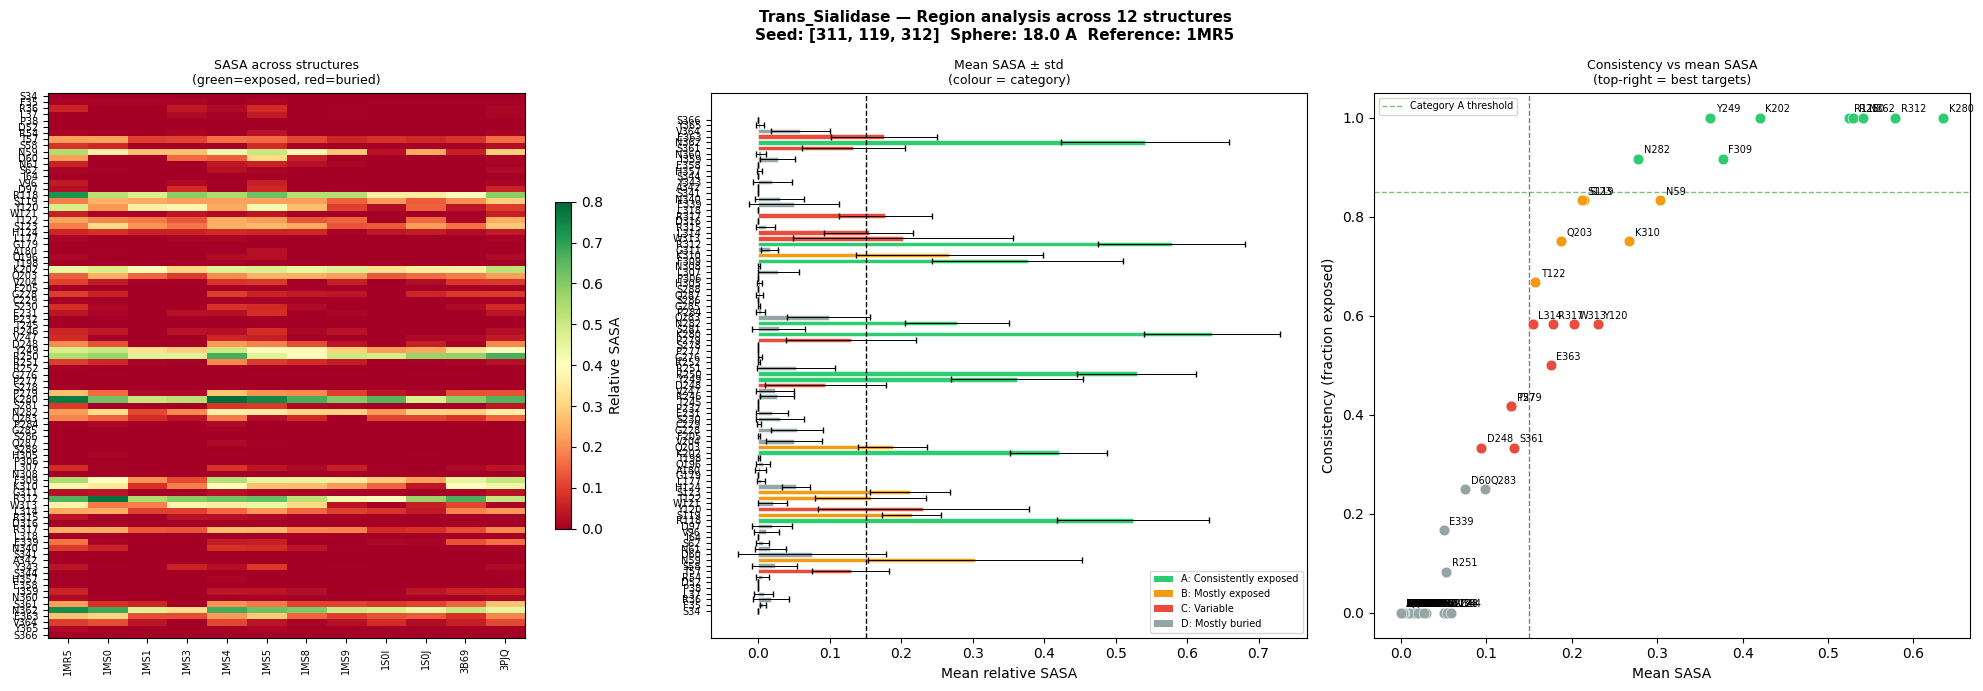

Figure saved: /mnt/c/Antibody Design/ts_region_analysis.png


In [26]:
# Cell 11: Visualisation
# 
# Three panels:
# Left: heatmap of SASA values — structures x residues (the transition matrix)
# Centre: mean SASA bar chart for the region coloured by category
# Right: consistency vs mean SASA scatter

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

struct_names = list(structures.keys())
region_positions = sorted(region_data.keys())
residue_labels = [f"{region_data[p]['uniprot_residue']}{p}" for p in region_positions]

# Build heatmap matrix
heatmap_data = np.zeros((len(region_positions), len(struct_names)))
for i, pos in enumerate(region_positions):
    for j, stem in enumerate(struct_names):
        val = region_data[pos]['per_structure'].get(stem, 0.0)
        heatmap_data[i, j] = val

ax = axes[0]
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.8)
ax.set_xticks(range(len(struct_names)))
ax.set_xticklabels(struct_names, rotation=90, fontsize=7)
ax.set_yticks(range(len(region_positions)))
ax.set_yticklabels(residue_labels, fontsize=7)
plt.colorbar(im, ax=ax, label='Relative SASA', shrink=0.6)
ax.set_title(f'SASA across structures\n(green=exposed, red=buried)', fontsize=9)
ax.axhline(y=-0.5, color='white', linewidth=0.5)

# Category colours
cat_colors = {
    'A_consistently_exposed': '#2ecc71',
    'B_mostly_exposed':       '#f39c12',
    'C_variable':             '#e74c3c',
    'D_mostly_buried':        '#95a5a6',
    'missing':                '#bdc3c7',
}
ax2 = axes[1]
colors = [cat_colors.get(region_data[p]['category'], '#bdc3c7') for p in region_positions]
bars = ax2.barh(range(len(region_positions)), 
                [region_data[p]['mean_sasa'] for p in region_positions],
                color=colors, edgecolor='white', linewidth=0.4)
ax2.errorbar(
    [region_data[p]['mean_sasa'] for p in region_positions],
    range(len(region_positions)),
    xerr=[region_data[p]['std_sasa'] for p in region_positions],
    fmt='none', color='black', capsize=2, linewidth=0.7
)
ax2.axvline(SASA_THRESHOLD, color='black', linestyle='--', linewidth=1,
            label=f'Threshold ({SASA_THRESHOLD})')
ax2.set_yticks(range(len(region_positions)))
ax2.set_yticklabels(residue_labels, fontsize=7)
ax2.set_xlabel('Mean relative SASA')
ax2.set_title('Mean SASA ± std\n(colour = category)', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='A: Consistently exposed'),
    Patch(facecolor='#f39c12', label='B: Mostly exposed'),
    Patch(facecolor='#e74c3c', label='C: Variable'),
    Patch(facecolor='#95a5a6', label='D: Mostly buried'),
]
ax2.legend(handles=legend_elements, fontsize=7, loc='lower right')

ax3 = axes[2]
for pos in region_positions:
    d = region_data[pos]
    c = cat_colors.get(d['category'], '#bdc3c7')
    ax3.scatter(d['mean_sasa'], d['consistency'],
                color=c, s=60, zorder=3, edgecolors='white', linewidths=0.4)
    ax3.annotate(f"{d['uniprot_residue']}{pos}",
                 (d['mean_sasa'], d['consistency']),
                 fontsize=7, xytext=(4, 4), textcoords='offset points')
ax3.axvline(SASA_THRESHOLD, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.axhline(0.85, color='green', linestyle='--', linewidth=1, alpha=0.5,
            label='Category A threshold')
ax3.set_xlabel('Mean SASA')
ax3.set_ylabel('Consistency (fraction exposed)')
ax3.set_title('Consistency vs mean SASA\n(top-right = best targets)', fontsize=9)
ax3.legend(fontsize=7)

plt.suptitle(
    f'{TARGET_NAME} — Region analysis across {len(structures)} structures\n'
    f'Seed: {SEED_RESIDUES}  Sphere: {SPHERE_RADIUS} A  '
    f'Reference: {REF_STRUCTURE}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

fig_path = output_dir / f'{TARGET_LABEL}_region_analysis.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')


In [27]:
# Cell 12: Save outputs for Notebook 01

output = {
    'target_name':          TARGET_NAME,
    'target_label':         TARGET_LABEL,
    'uniprot_accession':    UNIPROT_ACCESSION,
    'reference_structure':  REF_STRUCTURE,
    'reference_chain':      REF_CHAIN,
    'seed_residues':        SEED_RESIDUES,
    'sphere_radius':        SPHERE_RADIUS,
    'sasa_threshold':       SASA_THRESHOLD,
    'n_structures':         len(structures),
    'structures':           list(structures.keys()),
    'global_max_sasa':      global_max_sasa,
    'region_canonical':     sorted(list(region_canonical)),
    'candidate_pool_A':     candidate_pool_00a,
    'region_data':          {str(k): v for k, v in region_data.items()},
}

out_path = output_dir / f'{TARGET_LABEL}_consensus_sasa.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'NOTEBOOK 00a COMPLETE — {TARGET_NAME}')
print('=' * 60)
print(f'Structures     : {list(structures.keys())}')
print(f'Region size    : {len(region_data)} residues')
print(f'Category A     : {len(cat_A)} consistently exposed')
print(f'Category B     : {len(cat_B)} mostly exposed')
print(f'Output JSON    : {out_path}')
print()
print('Category A residues (candidate pool for Notebook 01):')
print(f'  {candidate_pool_00a}')


NOTEBOOK 00a COMPLETE — Trans_Sialidase
Structures     : ['1MR5', '1MS0', '1MS1', '1MS3', '1MS4', '1MS5', '1MS8', '1MS9', '1S0I', '1S0J', '3B69', '3PJQ']
Region size    : 88 residues
Category A     : 9 consistently exposed
Category B     : 6 mostly exposed
Output JSON    : /mnt/c/Antibody Design/ts_consensus_sasa.json

Category A residues (candidate pool for Notebook 01):
  [118, 202, 249, 250, 280, 282, 309, 312, 362]
